In [1]:
pip install pandas plotly nbformat nbclient ipywidgets matplotlib "urllib3<2"

You should consider upgrading via the '/Users/stripura/Desktop/ocp-workload-analysis-/venv/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


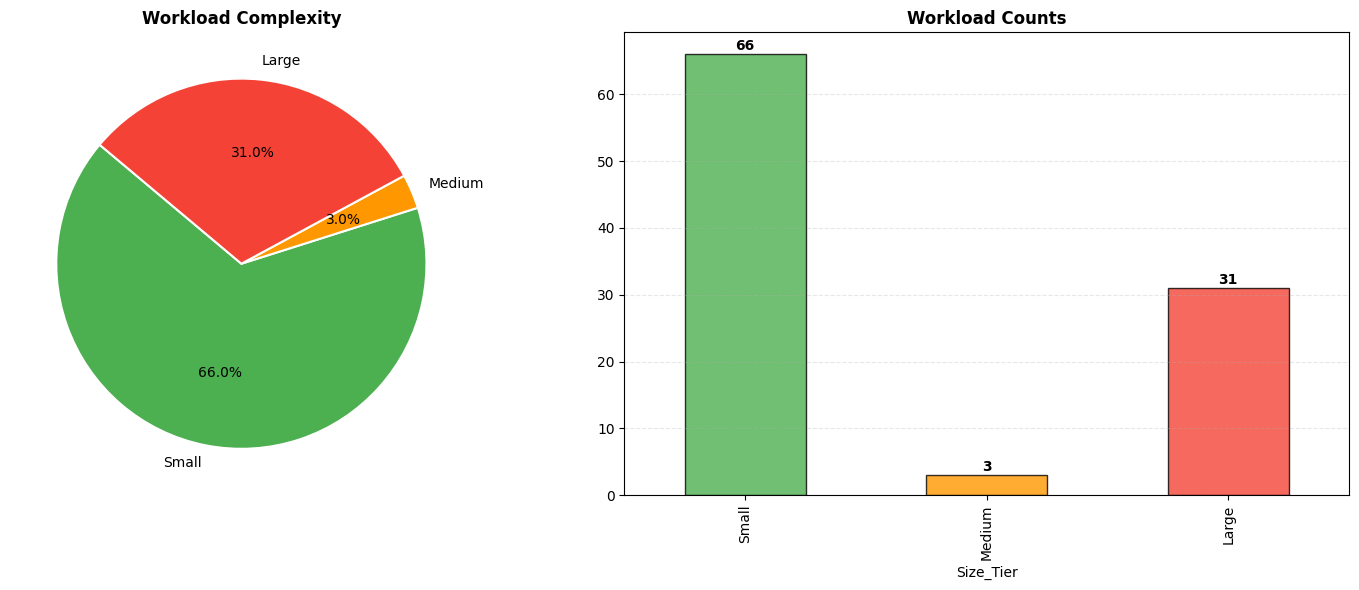

✅ Success! Results saved to current directory as: outputs/graded_k8s_sample_100_rows.csv


In [2]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import os

# --- 1. RESOURCE PARSERS ---

def parse_cpu(cpu_str):
    if pd.isna(cpu_str) or str(cpu_str) == '0' or str(cpu_str) == 'None': return 0.1
    cpu_str = str(cpu_str).lower()
    if cpu_str.endswith('m'): return int(cpu_str[:-1]) / 1000
    try: return float(cpu_str)
    except: return 0.1

def parse_mem(mem_str):
    if pd.isna(mem_str) or str(mem_str) == '0' or str(mem_str) == 'None': return 128
    mem_str = str(mem_str).lower()
    if 'gi' in mem_str: return float(mem_str.replace('gi', '')) * 1024
    if 'mi' in mem_str: return float(mem_str.replace('mi', ''))
    try: return float(mem_str) / (1024**2)
    except: return 128

# --- 2. CONFIG LOADER ---

def load_config(file_path='configs/workload_complexity_config.json'):
    # Default config if file doesn't exist
    default_cfg = {
        "weights": {"cpu_high": 3, "cpu_med": 1, "mem_high": 3, "mem_med": 1, "pvc_presence": 4, "net_complexity": 2},
        "thresholds": {"cpu_high": 2.0, "cpu_med": 0.5, "mem_high": 4096, "mem_med": 1024, "net_ports": 2, "tier_large": 7, "tier_medium": 3}
    }
    if os.path.exists(file_path):
        with open(file_path, 'r') as f:
            return json.load(f)
    return default_cfg

# --- 3. THE TIERING LOGIC (Using Config) ---

def assign_tier(row, cfg):
    score = 0
    w, t = cfg["weights"], cfg["thresholds"]
    
    # CPU & Mem logic
    if row.get('cpu_val', 0) >= t["cpu_high"]: score += w["cpu_high"]
    elif row.get('cpu_val', 0) >= t["cpu_med"]: score += w["cpu_med"]
    if row.get('mem_val', 0) >= t["mem_high"]: score += w["mem_high"]
    elif row.get('mem_val', 0) >= t["mem_med"]: score += w["mem_med"]
    
    # Extra weights
    if row.get('PVC_Count', 0) > 0: score += w["pvc_presence"]
    if row.get('Network_Interfaces_Ports', 1) > t["net_ports"]: score += w["net_complexity"]

    if score >= t["tier_large"]: return 'Large'
    if score >= t["tier_medium"]: return 'Medium'
    return 'Small'

# --- 4. THE DASHBOARD GENERATOR ---

def create_complex_dashboard(df, cfg_name="Default"):
    tier_order = ['Small', 'Medium', 'Large']
    counts = df['Size_Tier'].value_counts().reindex(tier_order, fill_value=0)
    colors = ['#4CAF50', '#FF9800', '#F44336']
    
    fig, (ax_pie, ax_bar) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Pie
    counts.plot(kind='pie', ax=ax_pie, autopct='%1.1f%%', colors=colors, startangle=140,
                wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
    ax_pie.set_title(f"Workload Complexity", fontweight='bold')
    ax_pie.set_ylabel('')

    # Bar
    counts.plot(kind='bar', ax=ax_bar, color=colors, edgecolor='black', alpha=0.8)
    ax_bar.set_title("Workload Counts", fontweight='bold')
    ax_bar.grid(axis='y', linestyle='--', alpha=0.3)
    
    for i, v in enumerate(counts):
        ax_bar.text(i, v + (max(counts)*0.01), str(v), ha='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

# --- 5. MAIN EXECUTION LOOP ---

def run_analysis(csv_file, config_file='configs/workload_complexity_config.json'):
    # Load Data
    df = pd.read_csv(csv_file)
    cfg = load_config(config_file)
    
    # Process
    df['cpu_val'] = df['CPU_Limit'].apply(parse_cpu)
    df['mem_val'] = df['Mem_Limit'].apply(parse_mem)
    df['Size_Tier'] = df.apply(lambda x: assign_tier(x, cfg), axis=1)
    
    # Display
    create_complex_dashboard(df, config_file)

    #Save graded file
    base_filename = os.path.basename(csv_file)
    output_name = f"outputs/graded_{base_filename}"
    
    try:
        df.to_csv(output_name, index=False)
        print(f"✅ Success! Results saved to current directory as: {output_name}")
    except Exception as e:
        print(f"❌ Error saving CSV: {e}")

# To run it, just call:
run_analysis('sample_data/k8s_sample_100_rows.csv')


✅ Successfully exported graded results to: outputs/graded_ns_complexity.csv


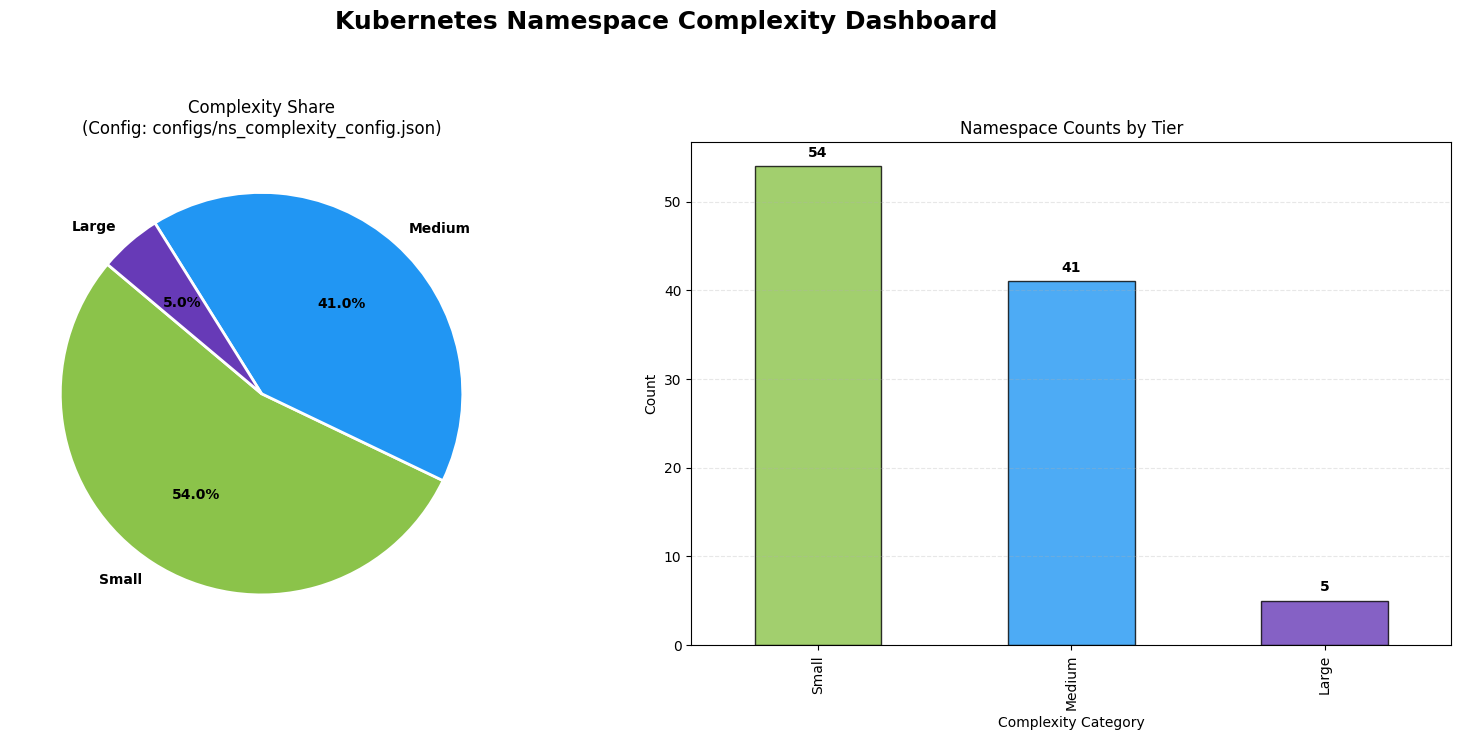

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import json
import os

# --- 1. CONFIG LOADER ---
def load_ns_config(file_path='configs/ns_complexity_config.json'):
    default_cfg = {
        "weights": {
            "workload_multiplier": 1.0,
            "pod_multiplier": 0.5,
            "pvc_multiplier": 3.0,
            "network_ops_multiplier": 2.0
        },
        "thresholds": {
            "tier_large": 50,
            "tier_medium": 15
        }
    }
    if os.path.exists(file_path):
        with open(file_path, 'r') as f:
            return json.load(f)
    return default_cfg

# --- 2. THE DYNAMIC GRADING FUNCTION ---
def assign_ns_tier(row, cfg):
    score = 0
    w = cfg["weights"]
    t = cfg["thresholds"]
    
    # Calculate weighted score
    workloads = row.get('Deployments', 0) + row.get('StatefulSets', 0)
    score += (workloads * w["workload_multiplier"])
    score += row.get('Pods', 0) * w["pod_multiplier"]
    score += row.get('PVCs', 0) * w["pvc_multiplier"]
    net_ops = row.get('NetworkPolicies', 0) + row.get('Ingress', 0)
    score += (net_ops * w["network_ops_multiplier"])

    # Determine Tier
    if score >= t["tier_large"]:
        return 'Large', score
    elif score >= t["tier_medium"]:
        return 'Medium', score
    else:
        return 'Small', score

# --- 3. THE UPDATED DASHBOARD HELPER (WITH EXPORT) ---
def create_ns_complexity_dashboard(df, config_path='configs/ns_complexity_config.json', output_dir='outputs'):
    # A. Setup Output Directory
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
        print(f"Created directory: {output_dir}")

    # B. Load the external config
    cfg = load_ns_config(config_path)
    
    # C. Apply Tiering and extract Score
    results = df.apply(lambda x: assign_ns_tier(x, cfg), axis=1)
    df['NS_Complexity_Tier'] = [r[0] for r in results]
    df['NS_Complexity_Score'] = [r[1] for r in results]
    
    # D. EXPORT THE DATA
    output_file = os.path.join(output_dir, 'graded_ns_complexity.csv')
    df.to_csv(output_file, index=False)
    print(f"✅ Successfully exported graded results to: {output_file}")
    
    # E. Data Preparation for Charting
    tier_order = ['Small', 'Medium', 'Large']
    counts = df['NS_Complexity_Tier'].value_counts().reindex(tier_order, fill_value=0)
    colors = ['#8BC34A', '#2196F3', '#673AB7'] 
    
    # Setup Figure
    fig, (ax_pie, ax_bar) = plt.subplots(1, 2, figsize=(16, 7))
    
    # Pie Chart
    counts.plot(kind='pie', ax=ax_pie, autopct='%1.1f%%', colors=colors, startangle=140,
                wedgeprops={'edgecolor': 'white', 'linewidth': 2}, textprops={'fontweight': 'bold'})
    ax_pie.set_title(f'Complexity Share\n(Config: {config_path})', fontsize=12)
    ax_pie.set_ylabel('')

    # Bar Chart
    counts.plot(kind='bar', ax=ax_bar, color=colors, edgecolor='black', alpha=0.8)
    ax_bar.set_title('Namespace Counts by Tier', fontsize=12)
    ax_bar.set_xlabel('Complexity Category')
    ax_bar.set_ylabel('Count')
    ax_bar.grid(axis='y', linestyle='--', alpha=0.3)
    
    for i, v in enumerate(counts):
        ax_bar.text(i, v + (max(counts) * 0.02), str(v), ha='center', fontweight='bold')

    plt.suptitle('Kubernetes Namespace Complexity Dashboard', fontsize=18, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()

# --- RUNNING THE ANALYSIS ---
# Ensure your sample file exists first
if os.path.exists('sample_data/k8s_ns_100_sample.csv'):
    df_ns = pd.read_csv('sample_data/k8s_ns_100_sample.csv')
    create_ns_complexity_dashboard(df_ns)
else:
    print("Error: Input CSV not found in 'sample_data/'")

✅ Success: Loaded outputs/graded_k8s_sample_100_rows.csv and outputs/graded_ns_complexity.csv
📂 Loaded migration config from: configs/migration_config.json
✅ Success: Loaded configs/migration_config.json configuration file


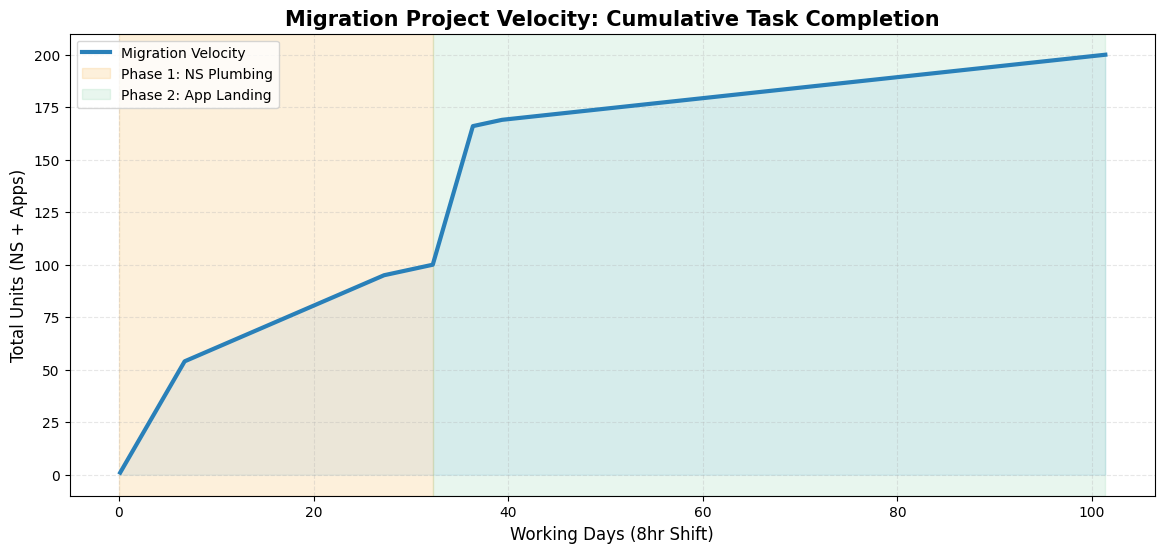


                CONSULTING ENGAGEMENT: MIGRATION SCOPE SUMMARY

[PHASE 1: WORKLOAD LANDING]
Tier         | Units    | Subtotal Hours 
----------------------------------------
Small        | 66       | 33.0           
Medium       | 3        | 24.0           
Large        | 31       | 496.0          

[PHASE 2: NAMESPACE PLUMBING]
Tier         | Units    | Subtotal Hours 
----------------------------------------
Small        | 54       | 54.0           
Medium       | 41       | 164.0          
Large        | 5        | 40.0           

GRAND TOTAL EFFORT: 811.0 Hours
ESTIMATED TIME (2 Engineers): 50.7 Working Days


Assumptions: 
--------------
App Migrations: 
1. Mature CI/CD in place.
2. Effort covers initial landing, connectivity and storage plumbing troubleshooting only.


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# --- CONFIG LOADER FUNCTION ---
def load_migration_config(file_path='configs/migration_config.json'):
    
    if os.path.exists(file_path):
        with open(file_path, 'r') as f:
            print(f"📂 Loaded migration config from: {file_path}")
            return json.load(f)
    else:
        print(f"⚠️ Config file not found at {file_path}. Using defaults.")
        return default_cfg
        
# --- SET FOLDER AND FIND FILES ---
wl_file = 'outputs/graded_k8s_sample_100_rows.csv'
ns_file = 'outputs/graded_ns_complexity.csv'
config_path = 'configs/migration_config.json'


if wl_file and ns_file:
    # --- LOAD DATA INTO MEMORY (Fixes the NameError) ---
    df_wl = pd.read_csv(wl_file)
    df_ns = pd.read_csv(ns_file)
    
    print(f"✅ Success: Loaded {wl_file} and {ns_file}")

    # Load Config from File
    MIGRATION_CONFIG = load_migration_config(config_path)

    print(f"✅ Success: Loaded {config_path} configuration file")

    # --- GENERATE THE LINEAR GRAPH & SUMMARY ---
    # (Executing the function logic directly to ensure no function NameErrors)
    
    wl_counts = df_wl['Size_Tier'].value_counts().reindex(['Small', 'Medium', 'Large'], fill_value=0)
    ns_counts = df_ns['NS_Complexity_Tier'].value_counts().reindex(['Small', 'Medium', 'Large'], fill_value=0)

    # Calculate Linear Effort
    ns_tasks = (['Small'] * ns_counts['Small'] + ['Medium'] * ns_counts['Medium'] + ['Large'] * ns_counts['Large'])
    wl_tasks = (['Small'] * wl_counts['Small'] + ['Medium'] * wl_counts['Medium'] + ['Large'] * wl_counts['Large'])
    
    all_efforts = [MIGRATION_CONFIG["ns_governance"][t] for t in ns_tasks] + \
                  [MIGRATION_CONFIG["workload_migration"][t] for t in wl_tasks]
    
    cumulative_hrs = np.cumsum(all_efforts)
    project_days = cumulative_hrs / 8
    task_indices = np.arange(1, len(all_efforts) + 1)

    # Plotting
    plt.figure(figsize=(14, 6))
    plt.plot(project_days, task_indices, color='#2980b9', linewidth=3, label='Migration Velocity')
    plt.fill_between(project_days, task_indices, color='#3498db', alpha=0.1)
    
    ns_end_day = project_days[len(ns_tasks)-1] if len(ns_tasks) > 0 else 0
    plt.axvspan(0, ns_end_day, color='#f39c12', alpha=0.15, label='Phase 1: NS Plumbing')
    plt.axvspan(ns_end_day, project_days[-1], color='#27ae60', alpha=0.1, label='Phase 2: App Landing')
    
    plt.title('Migration Project Velocity: Cumulative Task Completion', fontsize=15, fontweight='bold')
    plt.xlabel('Working Days (8hr Shift)', fontsize=12)
    plt.ylabel('Total Units (NS + Apps)', fontsize=12)
    plt.legend(loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.show()

    # --- PRINT THE SUMMARY TABLES ---
    print("\n" + "="*80)
    print("                CONSULTING ENGAGEMENT: MIGRATION SCOPE SUMMARY")
    print("="*80)
    print(f"\n[PHASE 1: WORKLOAD LANDING]")
    print(f"{'Tier':<12} | {'Units':<8} | {'Subtotal Hours':<15}")
    print("-" * 40)
    for tier in ['Small', 'Medium', 'Large']:
        c = wl_counts[tier]
        h = MIGRATION_CONFIG["workload_migration"][tier]
        print(f"{tier:<12} | {c:<8} | {c*h:<15,.1f}")
        
    print(f"\n[PHASE 2: NAMESPACE PLUMBING]")
    print(f"{'Tier':<12} | {'Units':<8} | {'Subtotal Hours':<15}")
    print("-" * 40)
    for tier in ['Small', 'Medium', 'Large']:
        c = ns_counts[tier]
        h = MIGRATION_CONFIG["ns_governance"][tier]
        print(f"{tier:<12} | {c:<8} | {c*h:<15,.1f}")
        
    total_hrs = cumulative_hrs[-1]
    print("\n" + "="*80)
    print(f"GRAND TOTAL EFFORT: {total_hrs:,.1f} Hours")
    print(f"ESTIMATED TIME (2 Engineers): {total_hrs/16:,.1f} Working Days")
    print("="*80)
    print("\n\nAssumptions: ")
    print("--------------")
    print("App Migrations: ")
    print("1. Mature CI/CD in place.")
    print("2. Effort covers initial landing, connectivity and storage plumbing troubleshooting only.")    
    print("="*80)

else:
    print("❌ Files not found in 'outputs/'. Check your naming!")